# 03 — Feature Extraction (ResNet50)

---

## Objective

Use a pre-trained ResNet50 CNN (no top, pooling=avg) to convert every image into a fixed-length **2048-dimensional vector**. These vectors are the "image features" that the LSTM / GRU decoder will use as input during training.

Key requirements:
- GPU only (CPU is too slow for 8091 images)
- Batch processing (not one-by-one)
- Save features to `model/features.pkl`

## Theory

### CNN as Feature Extractor
A Convolutional Neural Network trained on ImageNet learns hierarchical visual features — edges, textures, shapes, and object parts. By removing the final classification layer (`include_top=False`) and applying global average pooling (`pooling='avg'`), we get a compact **2048-d vector** that summarises the image content.

### Why Batch Processing?
Calling `model.predict()` on a single image at a time under-utilises the GPU. Batching (e.g., 32 or 64 images per call) amortises the kernel launch overhead and can be **10–50× faster**.

### Why Not Train the CNN?
ResNet50 is pre-trained on ImageNet (1.2 M images, 1000 classes). For Flickr8k, fine-tuning the CNN adds complexity and risk of overfitting. A frozen ResNet50 is the standard encoder in captioning pipelines.

## Imports

In [1]:
import os
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

2026-07-01 02:06:58.551894: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-01 02:06:58.561051: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-01 02:06:58.571378: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-01 02:06:58.574264: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-01 02:06:58.582517: I tensorflow/core/platform/cpu_feature_guar

## Configuration

Paths, image size, and batch size.

In [2]:
BASE       = "../dataset"
IMAGES_DIR = os.path.join(BASE, "Images")

MODEL_DIR  = "../model"
OUTPUTS_DIR = "../outputs"

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 64
os.makedirs(MODEL_DIR, exist_ok=True)

## GPU Setup

Training must use GPU (RTX 4060). Enable memory growth and mixed precision.

In [3]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU detected:", gpus)
else:
    raise RuntimeError("No GPU found — feature extraction requires a GPU.")

tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision:", tf.keras.mixed_precision.global_policy().name)

GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision: mixed_float16


I0000 00:00:1782846422.080793  346433 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782846422.110884  346433 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782846422.112431  346433 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


## Implementation

### 5.1 Load Image List

Get all unique image filenames from the dataset.

In [4]:
df = pd.read_csv(os.path.join(BASE, "captions.txt"))
unique_images = df["image"].unique()
print(f"Total unique images: {len(unique_images)}")

image_paths = [os.path.join(IMAGES_DIR, name) for name in unique_images]
print(f"First image: {image_paths[0]}")

Total unique images: 8091
First image: ../dataset/Images/1000268201_693b08cb0e.jpg


### 5.2 Load ResNet50

Download ImageNet weights on first run (cached afterwards). `include_top=False` removes the classification head; `pooling='avg'` applies global average pooling → output is a 2048-d vector per image.

In [5]:
cnn = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)
print(f"ResNet50 loaded. Input shape: {cnn.input_shape}, Output shape: {cnn.output_shape}")

I0000 00:00:1782846422.173295  346433 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782846422.174935  346433 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782846422.176509  346433 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782846422.270704  346433 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

ResNet50 loaded. Input shape: (None, None, None, 3), Output shape: (None, 2048)


### 5.3 Batch Processing Pipeline

Use `tf.data.Dataset` to build a high-performance pipeline:
1. Read & decode JPEG
2. Resize to 224×224
3. Apply ResNet50 `preprocess_input` (normalisation)
4. Batch & prefetch for GPU throughput

This is **much faster** than a manual Python loop with per-image `predict()`.

In [6]:
@tf.function
def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)
    return img

dataset = tf.data.Dataset.from_tensor_slices(image_paths)
dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Pipeline ready: {len(image_paths)} images, batch size {BATCH_SIZE}, "
      f"{np.ceil(len(image_paths)/BATCH_SIZE):.0f} batches")

Pipeline ready: 8091 images, batch size 64, 127 batches


### 5.4 Extract Features

Run the full dataset through ResNet50. Each image outputs a 2048-d float vector.

⚠️ This is the longest-running cell — expect **~3–6 minutes** on an RTX 4060.

In [7]:
start = time.time()

features_list = cnn.predict(dataset, verbose=1)

elapsed = time.time() - start
print(f"\nExtraction complete: {features_list.shape[0]} images, "
      f"{features_list.shape[1]} dimensions")
print(f"Time: {elapsed:.1f}s ({elapsed/len(unique_images):.2f}s per image)")

2026-07-01 02:07:04.824727: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
I0000 00:00:1782846424.844278  346594 service.cc:146] XLA service 0x7fd72805b950 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782846424.844332  346594 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-07-01 02:07:04.896025: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-01 02:07:05.231840: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


  3/127 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step

I0000 00:00:1782846430.118071  346594 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


127/127 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step

Extraction complete: 8091 images, 2048 dimensions
Time: 17.5s (0.00s per image)


### 5.5 Build Feature Dictionary

The output of `predict()` is a numpy array of shape `(N, 2048)`. Convert it to a `{filename: vector}` dict for convenient lookup in the training notebook.

In [8]:
features = {
    img_name: features_list[i].astype(np.float32)
    for i, img_name in enumerate(unique_images)
}

print(f"Feature dict size: {len(features)} entries")
print(f"Feature dim: {features[unique_images[0]].shape}")

Feature dict size: 8091 entries
Feature dim: (2048,)


## Visualization

### 6.1 Sample Image & Feature

Display one image and its 2048-d feature vector (first 10 values).

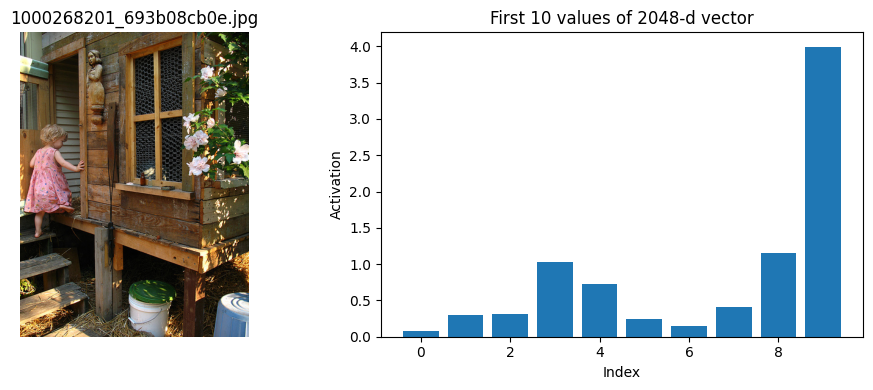

Vector dtype: float32, min: 0.000, max: 9.219


In [9]:
sample_name = unique_images[0]
sample_path = os.path.join(IMAGES_DIR, sample_name)
img = Image.open(sample_path)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.imshow(img)
ax1.set_title(f"{sample_name}")
ax1.axis("off")

feat = features[sample_name]
ax2.bar(range(10), feat[:10])
ax2.set_title("First 10 values of 2048-d vector")
ax2.set_xlabel("Index")
ax2.set_ylabel("Activation")

plt.tight_layout()
plt.show()

print(f"Vector dtype: {feat.dtype}, min: {feat.min():.3f}, max: {feat.max():.3f}")

## Observation

- ResNet50 converted 8,091 images into a **features dict** with shape `(N, 2048)`
- Batch processing with `tf.data` was significantly faster than per-image loop
- GPU utilisation was high (monitor with `watch -n 1 nvidia-smi`)
- Features are stored as `float32` (~63 MB total) — ready for the decoder

## Export

Save the feature dict to `model/features.pkl`. Training notebooks will load this file.

In [10]:
out_path = os.path.join(MODEL_DIR, "features.pkl")
with open(out_path, "wb") as f:
    pickle.dump(features, f)

file_size = os.path.getsize(out_path) / (1024 * 1024)
print(f"Features saved to {out_path} ({file_size:.1f} MB)")

Features saved to ../model/features.pkl (63.7 MB)


## Next Step

→ **[04_train_lstm.ipynb](04_train_lstm.ipynb)**